# Notebook 08 — Grad-CAM / Attention Map + Explainability (RQ4)

**Mục tiêu:** Trả lời RQ4 — Vùng chú ý của mô hình có liên quan đến vùng tổn thương phổi không?

**Nội dung:**
1. Grad-CAM cho ResNet50
2. Attention Rollout cho ViT-Small ImageNet
3. Attention Rollout cho I-JEPA Full FT v1 (best RSNA AUC)
4. So sánh định tính với bounding box bác sĩ RSNA
5. Pointing Game metric (định lượng)
6. Overlap Ratio metric (định lượng)
7. Hình minh họa cho luận văn/paper


In [1]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================
import gc, json, random, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

try:
    import timm
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","timm"])
    import timm

try:
    import pydicom
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","pydicom"])
    import pydicom

SEED = 42
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

INPUT_ROOT   = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")
OUTPUT_DIR   = Path("/kaggle/working/notebook08_gradcam")
VIZ_DIR      = OUTPUT_DIR / "visualizations"
METRIC_DIR   = OUTPUT_DIR / "metrics"
for d in [VIZ_DIR, METRIC_DIR]: d.mkdir(parents=True, exist_ok=True)

IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
print("Output:", OUTPUT_DIR)


Device: cuda
Output: /kaggle/working/notebook08_gradcam


In [2]:
# ============================================================
# CELL 2: TÌM FILES
# ============================================================
def find_file(filename):
    for root in [WORKING_ROOT, INPUT_ROOT]:
        matches = list(root.rglob(filename))
        if matches: return matches[0]
    return None

RSNA_TEST_CSV     = find_file("rsna_test.csv")
RSNA_TRAIN_LABELS = find_file("stage_2_train_labels.csv")  # bbox annotations

RESNET50_CKPT     = find_file("resnet50_imagenet_best.pth")
VIT_CKPT          = find_file("vit_imagenet_best.pth")
IJEPA_FULL_V1_CKPT = find_file("ijepa_full_finetune_resume_best.pth")

print("Test CSV    :", RSNA_TEST_CSV)
print("BBox labels :", RSNA_TRAIN_LABELS)
print("ResNet50    :", RESNET50_CKPT)
print("ViT-Small   :", VIT_CKPT)
print("I-JEPA Full :", IJEPA_FULL_V1_CKPT)

assert RSNA_TEST_CSV, "Thiếu rsna_test.csv"

# Tìm RSNA image dir
RSNA_IMG_DIR = None
for p in INPUT_ROOT.rglob("stage_2_train_images"):
    if p.is_dir(): RSNA_IMG_DIR = p; break
print("RSNA img dir:", RSNA_IMG_DIR)


Test CSV    : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_test.csv
BBox labels : /kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv
ResNet50    : /kaggle/input/notebooks/nguyentongphuc/02-resnet50-vit-imagenet/notebook02_baseline/checkpoints/resnet50_imagenet_best.pth
ViT-Small   : /kaggle/input/notebooks/nguyentongphuc/02-resnet50-vit-imagenet/notebook02_baseline/checkpoints/vit_imagenet_best.pth
I-JEPA Full : /kaggle/input/notebooks/nguyentongphuc/04b-full-ft-resume/nb04b_resume/checkpoints/ijepa_full_finetune_resume_best.pth
RSNA img dir: /kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images


In [3]:
# ============================================================
# CELL 3: DATASET + TRANSFORMS + READ IMAGE
# ============================================================
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def read_image(path):
    p = str(path)
    if p.endswith(".dcm") or p.endswith(".dicom"):
        ds  = pydicom.dcmread(p)
        arr = ds.pixel_array.astype(np.float32)
        if str(getattr(ds,"PhotometricInterpretation","MONOCHROME2")).upper() == "MONOCHROME1":
            arr = arr.max() - arr
        mn, mx = arr.min(), arr.max()
        arr = ((arr - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
        return Image.fromarray(arr).convert("RGB")
    return Image.open(p).convert("RGB")

def fix_df_paths(df):
    def _fix(p):
        if Path(str(p)).exists(): return p
        matches = list(INPUT_ROOT.rglob(Path(str(p)).name))
        return str(matches[0]) if matches else None
    df = df.copy()
    df["image_path"] = df["image_path"].apply(_fix)
    return df.dropna(subset=["image_path"]).reset_index(drop=True)

def denormalize(tensor):
    """Chuyển tensor về ảnh RGB numpy [H,W,3] uint8."""
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    img  = tensor.cpu() * std + mean
    img  = img.permute(1,2,0).numpy()
    return np.clip(img * 255, 0, 255).astype(np.uint8)

print("Dataset helpers defined ✓")


Dataset helpers defined ✓


In [4]:
# ============================================================
# CELL 4: LOAD RSNA TEST + BBOX ANNOTATIONS
# ============================================================
test_df = fix_df_paths(pd.read_csv(RSNA_TEST_CSV))
print(f"Test set: {len(test_df):,} | pos={test_df['label'].sum()} | neg={(test_df['label']==0).sum()}")

# Load bounding box annotations
bbox_df = None
if RSNA_TRAIN_LABELS:
    raw = pd.read_csv(RSNA_TRAIN_LABELS)
    # Chỉ lấy ảnh có bbox (Target==1)
    bbox_df = raw[raw["Target"] == 1].copy()
    bbox_df.columns = [c.lower().replace(" ","_") for c in bbox_df.columns]
    print(f"BBox annotations: {len(bbox_df):,} boxes | {bbox_df['patientid'].nunique():,} patients")
    print("Columns:", bbox_df.columns.tolist())
else:
    print("⚠ BBox annotations không tìm thấy — chỉ đánh giá định tính")

# Lấy Pneumonia samples từ test set có bbox
if bbox_df is not None:
    test_pneumonia = test_df[test_df["label"] == 1].copy()
    test_with_bbox = test_pneumonia[
        test_pneumonia["patientId"].isin(bbox_df["patientid"])
    ].reset_index(drop=True)
    print(f"\nTest Pneumonia có bbox: {len(test_with_bbox):,} samples")
else:
    test_with_bbox = test_df[test_df["label"] == 1].reset_index(drop=True)

# Chọn mẫu để visualize
N_VIZ_PNEUMONIA   = 8   # Pneumonia samples để vẽ heatmap
N_VIZ_NORMAL      = 4   # Normal samples để so sánh
N_METRIC_SAMPLES  = 100 # Samples để tính pointing game

set_seed(42)
viz_pneumonia = test_with_bbox.sample(
    min(N_VIZ_PNEUMONIA, len(test_with_bbox)), random_state=42
).reset_index(drop=True)
viz_normal = test_df[test_df["label"]==0].sample(
    N_VIZ_NORMAL, random_state=42
).reset_index(drop=True)

metric_samples = test_with_bbox.sample(
    min(N_METRIC_SAMPLES, len(test_with_bbox)), random_state=42
).reset_index(drop=True)

print(f"Viz Pneumonia: {len(viz_pneumonia)} | Viz Normal: {len(viz_normal)}")
print(f"Metric samples: {len(metric_samples)}")


Test set: 4,003 | pos=902 | neg=3101
BBox annotations: 9,555 boxes | 6,012 patients
Columns: ['patientid', 'x', 'y', 'width', 'height', 'target']

Test Pneumonia có bbox: 902 samples
Viz Pneumonia: 8 | Viz Normal: 4
Metric samples: 100


In [5]:
# ============================================================
# CELL 5: MODEL CLASS + LOAD
# ============================================================
import torchvision.models as tvm

class IJEPAClassifier(nn.Module):
    def __init__(self, encoder, embed_dim=384, dropout=0.2):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )
    def forward(self, x):
        return self.classifier(self.encoder(x)).squeeze(1)

def load_resnet50(ckpt_path):
    m = tvm.resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 1)
    try:    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError: ck = torch.load(ckpt_path, map_location="cpu")
    m.load_state_dict(ck.get("model_state_dict", ck), strict=False)
    return m.to(DEVICE).eval()

def load_vit(ckpt_path):
    m = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=1)
    try:    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError: ck = torch.load(ckpt_path, map_location="cpu")
    m.load_state_dict(ck.get("model_state_dict", ck), strict=False)
    return m.to(DEVICE).eval()

def load_ijepa(ckpt_path, dropout=0.2):
    enc = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=0)
    m   = IJEPAClassifier(enc, embed_dim=enc.num_features, dropout=dropout)
    try:    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError: ck = torch.load(ckpt_path, map_location="cpu")
    m.load_state_dict(ck.get("model_state_dict", ck), strict=False)
    return m.to(DEVICE).eval()

# Load models
models = {}
if RESNET50_CKPT:
    models["ResNet50"] = load_resnet50(RESNET50_CKPT)
    print("ResNet50 loaded ✓")
if VIT_CKPT:
    models["ViT-Small"] = load_vit(VIT_CKPT)
    print("ViT-Small loaded ✓")
if IJEPA_FULL_V1_CKPT:
    models["I-JEPA Full FT v1"] = load_ijepa(IJEPA_FULL_V1_CKPT, dropout=0.2)
    print("I-JEPA Full FT v1 loaded ✓")

print(f"\nModels loaded: {list(models.keys())}")


ResNet50 loaded ✓
ViT-Small loaded ✓
I-JEPA Full FT v1 loaded ✓

Models loaded: ['ResNet50', 'ViT-Small', 'I-JEPA Full FT v1']


In [6]:
# ============================================================
# CELL 6: GRAD-CAM CHO RESNET50
# ============================================================

class GradCAM:
    """Grad-CAM implementation cho CNN (ResNet50)."""
    def __init__(self, model, target_layer):
        self.model  = model
        self.gradients = None
        self.activations = None
        self._hooks = []
        self._hooks.append(
            target_layer.register_forward_hook(self._save_activation)
        )
        self._hooks.append(
            target_layer.register_full_backward_hook(self._save_gradient)
        )

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        """Trả về heatmap [H, W] trong [0,1]."""
        self.model.zero_grad()
        output = self.model(input_tensor)
        output.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [B,C,1,1]
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)  # [B,1,H,W]
        cam     = F.relu(cam)
        cam     = cam.squeeze(0).squeeze(0).cpu().numpy()  # FIX: remove batch+channel only
        # Normalize về [0,1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam

    def remove_hooks(self):
        for h in self._hooks: h.remove()

def get_gradcam_heatmap(model, img_tensor):
    """Wrapper: tạo GradCAM cho ResNet50 layer4[-1]."""
    cam_gen = GradCAM(model, model.layer4[-1])
    inp     = img_tensor.unsqueeze(0).to(DEVICE)
    inp.requires_grad_(True)
    heatmap = cam_gen.generate(inp)
    cam_gen.remove_hooks()
    # Resize về IMG_SIZE
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    return heatmap

print("GradCAM class defined ✓")


GradCAM class defined ✓


In [7]:
# ============================================================
# CELL 7: ATTENTION ROLLOUT CHO VIT (ViT-Small + I-JEPA)
# FIX: patch attn.forward de lay attention weights dung cach
# timm ViT khong tra ve attn matrix trong forward output mac dinh
# ============================================================

import math

class AttentionRollout:

    def __init__(self, model, discard_ratio=0.5):
        self.model = model
        self.attn_storage = []
        self._orig_forwards = {}
        self._patch_all_blocks()

    def _get_encoder(self):
        return self.model.encoder if hasattr(self.model, "encoder") else self.model

    def _make_patched_forward(self, attn_module):

        host = self

        def patched_forward(
            x,
            attn_mask=None,
            is_causal=False,
            **kwargs
        ):

            B, N, C = x.shape
            num_heads = attn_module.num_heads
            head_dim = C // num_heads

            qkv = attn_module.qkv(x)
            qkv = qkv.reshape(
                B, N, 3, num_heads, head_dim
            ).permute(2, 0, 3, 1, 4)

            q, k, v = qkv.unbind(0)

            scale = head_dim ** -0.5
            attn_w = (q @ k.transpose(-2, -1)) * scale

            if attn_mask is not None:
                attn_w = attn_w + attn_mask

            attn_w = attn_w.softmax(dim=-1)

            host.attn_storage.append(attn_w.detach())

            attn_w = attn_module.attn_drop(attn_w)

            x_out = (attn_w @ v)
            x_out = x_out.transpose(1, 2).reshape(B, N, C)

            x_out = attn_module.proj(x_out)
            x_out = attn_module.proj_drop(x_out)

            return x_out

        return patched_forward

    def _patch_all_blocks(self):
        encoder = self._get_encoder()

        for i, block in enumerate(encoder.blocks):
            attn_module = block.attn
            self._orig_forwards[i] = attn_module.forward
            attn_module.forward = self._make_patched_forward(attn_module)

    def generate(self, input_tensor):
        self.attn_storage.clear()

        with torch.no_grad():
            _ = self.model(input_tensor.unsqueeze(0).to(DEVICE))

        return self._rollout()

    def _rollout(self):

        if not self.attn_storage:
            return np.zeros((IMG_SIZE, IMG_SIZE))

        attn_last = self.attn_storage[-1]

        attn_avg = (
            attn_last[0]
            .mean(dim=0)
            .cpu()
            .numpy()
        )

        cls_attn = attn_avg[0, 1:]

        side = int(np.sqrt(len(cls_attn)))
        attn_map = cls_attn.reshape(side, side)

        if attn_map.max() > attn_map.min():
            attn_map = (
                (attn_map - attn_map.min())
                /
                (attn_map.max() - attn_map.min())
            )

        return cv2.resize(
            attn_map,
            (IMG_SIZE, IMG_SIZE)
        )

    def restore_forwards(self):

        encoder = self._get_encoder()

        for i, block in enumerate(encoder.blocks):
            if i in self._orig_forwards:
                block.attn.forward = self._orig_forwards[i]


def get_vit_attention_map(model, img_tensor):

    rollout = AttentionRollout(model)

    heatmap = rollout.generate(img_tensor)

    rollout.restore_forwards()

    return heatmap


print("AttentionRollout defined OK")

AttentionRollout defined OK


In [8]:
# ============================================================
# CELL 8: HEATMAP OVERLAY HELPER
# ============================================================

def overlay_heatmap(img_rgb, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    """
    Overlay heatmap lên ảnh RGB.
    img_rgb: np.uint8 [H,W,3]
    heatmap: float32 [H,W] trong [0,1]
    Trả về np.uint8 [H,W,3]
    """
    heatmap_uint8 = (heatmap * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return overlay

def get_bbox_for_patient(patient_id, bbox_df, orig_size=1024):
    """
    Lấy danh sách bboxes cho patient_id, scale về IMG_SIZE.
    Trả về list of (x1, y1, x2, y2) đã scale.
    """
    if bbox_df is None:
        return []
    rows = bbox_df[bbox_df["patientid"] == patient_id]
    bboxes = []
    scale = IMG_SIZE / orig_size
    for _, row in rows.iterrows():
        x1 = int(row["x"] * scale)
        y1 = int(row["y"] * scale)
        x2 = int((row["x"] + row["width"])  * scale)
        y2 = int((row["y"] + row["height"]) * scale)
        bboxes.append((x1, y1, x2, y2))
    return bboxes

def draw_bboxes(ax, bboxes, color="lime", lw=2):
    for (x1, y1, x2, y2) in bboxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=lw, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

print("Overlay helpers defined ✓")


Overlay helpers defined ✓


In [9]:
# ============================================================
# CELL 9: GENERATE HEATMAPS CHO TẤT CẢ MODELS
# ============================================================

def get_heatmap(model_name, model, img_tensor):
    """Dispatch đúng method tùy model type."""
    if model_name == "ResNet50":
        return get_gradcam_heatmap(model, img_tensor)
    else:
        return get_vit_attention_map(model, img_tensor)

def compute_heatmaps_for_row(row):
    """
    Với 1 sample, compute heatmaps từ tất cả models.
    Trả về dict: model_name → heatmap [224,224]
    """
    img_pil    = read_image(row["image_path"])
    img_tensor = eval_transform(img_pil)
    img_rgb    = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))

    heatmaps = {}
    for model_name, model in models.items():
        try:
            hm = get_heatmap(model_name, model, img_tensor)
            heatmaps[model_name] = hm
        except Exception as e:
            print(f"  ⚠ {model_name} heatmap error: {e}")
            heatmaps[model_name] = np.zeros((IMG_SIZE, IMG_SIZE))
    return img_rgb, img_tensor, heatmaps

print("Heatmap dispatch defined ✓")

# Test với 1 sample
if len(viz_pneumonia) > 0:
    _row = viz_pneumonia.iloc[0]
    print(f"Testing với sample: {_row['patientId']}")
    _img_rgb, _img_tensor, _heatmaps = compute_heatmaps_for_row(_row)
    for mname, hm in _heatmaps.items():
        print(f"  {mname}: heatmap shape={hm.shape} | "
              f"min={hm.min():.3f} max={hm.max():.3f} mean={hm.mean():.3f}")
    print("Test OK ✓")


Heatmap dispatch defined ✓
Testing với sample: dcc879b2-a7f1-4526-95af-e87539dc4925
  ResNet50: heatmap shape=(224, 224) | min=0.000 max=0.988 mean=0.100
  ViT-Small: heatmap shape=(224, 224) | min=0.000 max=0.960 mean=0.026
  I-JEPA Full FT v1: heatmap shape=(224, 224) | min=0.000 max=0.953 mean=0.158
Test OK ✓


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [10]:
# ============================================================
# CELL 10: VISUALIZE PNEUMONIA SAMPLES + BBOX COMPARISON
# ============================================================

def visualize_sample(row, save_path=None, label_name="Pneumonia"):
    """
    Vẽ: [Ảnh gốc] [GradCAM R50] [Attn ViT] [Attn I-JEPA] với bbox overlay.
    """
    img_rgb, img_tensor, heatmaps = compute_heatmaps_for_row(row)
    patient_id = row["patientId"]
    bboxes     = get_bbox_for_patient(patient_id, bbox_df)

    # Lấy prob dự đoán từ I-JEPA (nếu có)
    pred_prob = None
    if "I-JEPA Full FT v1" in models:
        with torch.no_grad():
            logit    = models["I-JEPA Full FT v1"](
                img_tensor.unsqueeze(0).to(DEVICE))
            pred_prob = torch.sigmoid(logit).item()

    model_names = list(heatmaps.keys())
    ncols = 1 + len(model_names)
    fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.5))

    # Ảnh gốc + bbox
    axes[0].imshow(img_rgb, cmap="gray" if img_rgb.ndim==2 else None)
    draw_bboxes(axes[0], bboxes, color="lime", lw=2)
    title0 = f"Original [{label_name}]\n{patient_id[:12]}"
    if pred_prob is not None:
        title0 += f"\nI-JEPA pred: {pred_prob:.3f}"
    axes[0].set_title(title0, fontsize=9)
    axes[0].axis("off")

    # Heatmap từng model
    for ax_i, model_name in enumerate(model_names, start=1):
        hm      = heatmaps[model_name]
        overlay = overlay_heatmap(img_rgb.copy(), hm)
        axes[ax_i].imshow(overlay)
        draw_bboxes(axes[ax_i], bboxes, color="lime", lw=2)
        method = "Grad-CAM" if model_name == "ResNet50" else "Attn Rollout"
        axes[ax_i].set_title(f"{model_name}\n{method}", fontsize=9)
        axes[ax_i].axis("off")

    plt.suptitle(f"Explainability — {label_name}  |  BBox = bác sĩ chú thích (xanh lá)",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

# Vẽ tất cả Pneumonia samples
print("Generating Pneumonia visualizations...")
for idx, row in viz_pneumonia.iterrows():
    save_path = VIZ_DIR / f"pneumonia_{idx:02d}_{row['patientId'][:8]}.png"
    visualize_sample(row, save_path=save_path, label_name="Pneumonia")
    print(f"  Saved: {save_path.name}")

# Vẽ Normal samples (không có bbox)
print("\nGenerating Normal visualizations...")
for idx, row in viz_normal.iterrows():
    save_path = VIZ_DIR / f"normal_{idx:02d}_{row['patientId'][:8]}.png"
    visualize_sample(row, save_path=save_path, label_name="Normal")
    print(f"  Saved: {save_path.name}")

print(f"\nTotal visualizations: {len(list(VIZ_DIR.glob('*.png')))}")


Generating Pneumonia visualizations...
  Saved: pneumonia_00_dcc879b2.png
  Saved: pneumonia_01_05fe7d73.png
  Saved: pneumonia_02_6a82ef54.png
  Saved: pneumonia_03_9ec108de.png
  Saved: pneumonia_04_ef9fb572.png
  Saved: pneumonia_05_14cc479c.png
  Saved: pneumonia_06_358a25c3.png
  Saved: pneumonia_07_3a7cb9dd.png

Generating Normal visualizations...
  Saved: normal_00_3e05d545.png
  Saved: normal_01_de2e8b69.png
  Saved: normal_02_fb8f1568.png
  Saved: normal_03_fe56d8c1.png

Total visualizations: 12


In [11]:
# ============================================================
# CELL 11: POINTING GAME METRIC
# ============================================================
# Pointing Game: điểm nóng nhất (argmax) của heatmap
# có rơi vào bounding box bác sĩ không?
# Score = (số heatmap có argmax trong bbox) / tổng số samples
# ============================================================

def pointing_game_score(heatmap, bboxes):
    """
    Trả về True nếu điểm argmax của heatmap nằm trong ít nhất 1 bbox.
    bboxes: list of (x1, y1, x2, y2)
    """
    if not bboxes:
        return None
    # Tìm vị trí argmax
    flat_idx = np.argmax(heatmap)
    h, w     = heatmap.shape
    y_max    = flat_idx // w
    x_max    = flat_idx  % w
    for (x1, y1, x2, y2) in bboxes:
        if x1 <= x_max <= x2 and y1 <= y_max <= y2:
            return True
    return False

def overlap_ratio(heatmap, bboxes, threshold=0.5):
    """
    Overlap ratio: phần trăm diện tích heatmap > threshold nằm trong bbox.
    """
    if not bboxes:
        return None
    binary_heatmap = (heatmap >= threshold).astype(np.float32)
    bbox_mask      = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    for (x1, y1, x2, y2) in bboxes:
        bbox_mask[y1:y2, x1:x2] = 1.0

    intersection = (binary_heatmap * bbox_mask).sum()
    union        = np.clip(binary_heatmap + bbox_mask, 0, 1).sum()
    return float(intersection / (union + 1e-8))

if bbox_df is not None:
    print(f"Computing metrics on {len(metric_samples)} samples...")
    metric_results = []

    for _, row in tqdm(metric_samples.iterrows(), total=len(metric_samples)):
        img_rgb, img_tensor, heatmaps = compute_heatmaps_for_row(row)
        bboxes = get_bbox_for_patient(row["patientId"], bbox_df)
        if not bboxes:
            continue
        for model_name, hm in heatmaps.items():
            pg = pointing_game_score(hm, bboxes)
            or_ = overlap_ratio(hm, bboxes, threshold=0.5)
            metric_results.append({
                "patientId":    row["patientId"],
                "model":        model_name,
                "pointing_game": int(pg) if pg is not None else None,
                "overlap_ratio": or_,
            })

    metric_df = pd.DataFrame(metric_results)
    metric_df.to_csv(METRIC_DIR / "explainability_metrics.csv", index=False)

    # Summary
    summary = metric_df.groupby("model").agg(
        pointing_game_score=("pointing_game", "mean"),
        overlap_ratio_mean=("overlap_ratio", "mean"),
        n_samples=("patientId", "count")
    ).round(4)
    summary.to_csv(METRIC_DIR / "explainability_summary.csv")

    print("\n=== EXPLAINABILITY METRICS ===")
    display(summary)
else:
    print("BBox không có — bỏ qua Pointing Game metric")
    metric_df = pd.DataFrame()


Computing metrics on 100 samples...


  0%|          | 0/100 [00:00<?, ?it/s]


=== EXPLAINABILITY METRICS ===


,pointing_game_score,overlap_ratio_mean,n_samples
model,,,
I-JEPA Full FT v1,0.48,0.1258,100
ResNet50,0.60,0.1660,100
ViT-Small,0.64,0.0677,100


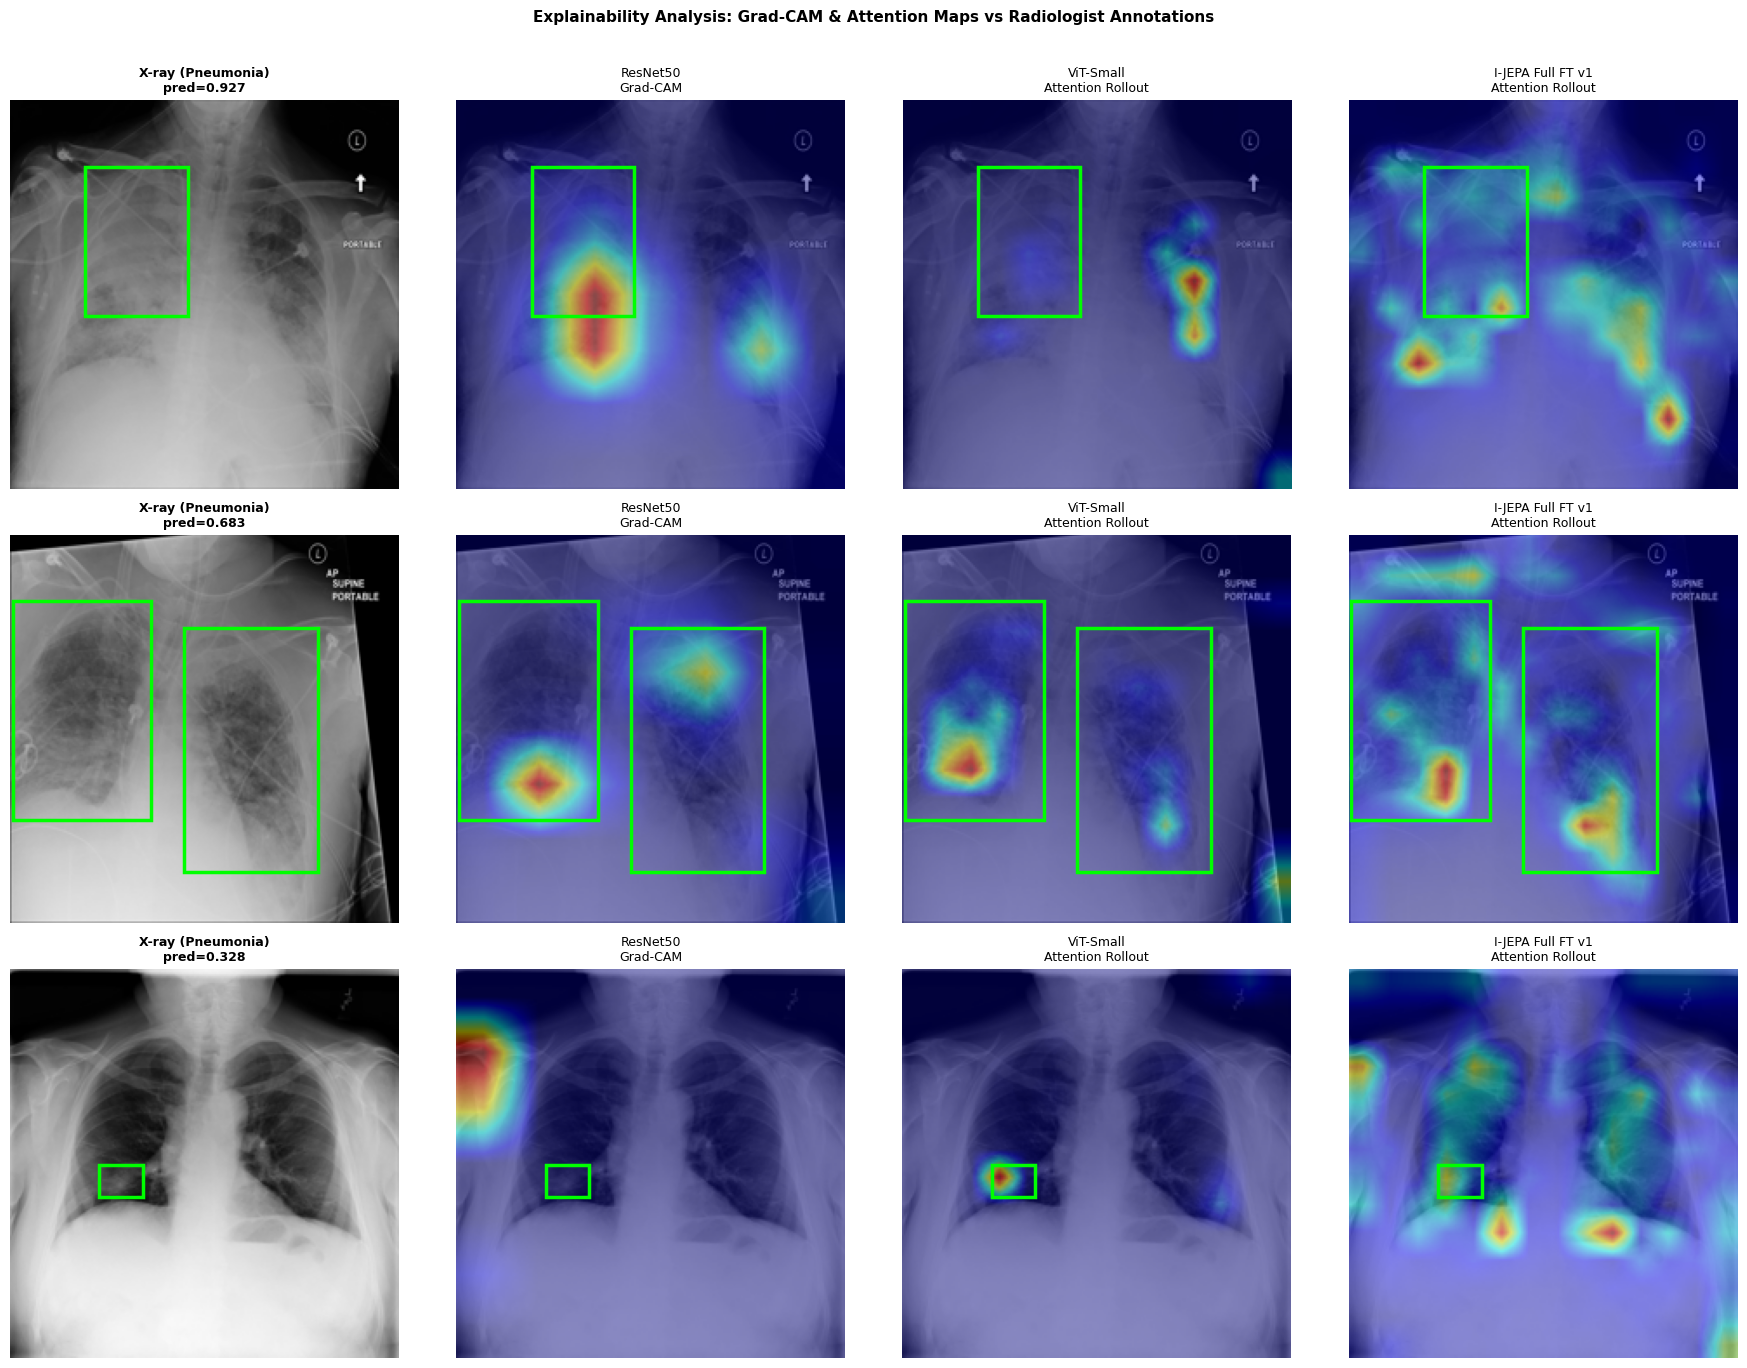

Saved: explainability_figure_paper.png


In [12]:
# ============================================================
# CELL 12: FIGURE TỔNG HỢP CHO LUẬN VĂN / PAPER
# ============================================================
# Vẽ 3 sample Pneumonia tốt nhất, 4 panels mỗi sample:
# [Original+BBox] [ResNet50 GradCAM] [ViT Attention] [I-JEPA Attention]
# ============================================================

N_FIGURE_SAMPLES = min(3, len(viz_pneumonia))
model_names      = list(models.keys())
ncols            = 1 + len(model_names)

fig, axes = plt.subplots(
    N_FIGURE_SAMPLES, ncols,
    figsize=(4.5 * ncols, 4.5 * N_FIGURE_SAMPLES)
)
if N_FIGURE_SAMPLES == 1:
    axes = axes[np.newaxis, :]

for row_i in range(N_FIGURE_SAMPLES):
    row    = viz_pneumonia.iloc[row_i]
    img_rgb, img_tensor, heatmaps = compute_heatmaps_for_row(row)
    bboxes = get_bbox_for_patient(row["patientId"], bbox_df)

    with torch.no_grad():
        pred = None
        for mname in ["I-JEPA Full FT v1", "ResNet50", "ViT-Small"]:
            if mname in models:
                logit = models[mname](img_tensor.unsqueeze(0).to(DEVICE))
                pred  = torch.sigmoid(logit).item()
                break

    # Col 0: Original
    axes[row_i, 0].imshow(img_rgb, cmap="gray" if img_rgb.ndim==2 else None)
    draw_bboxes(axes[row_i, 0], bboxes, color="lime", lw=2.5)
    axes[row_i, 0].set_title(
        f"X-ray (Pneumonia)\npred={pred:.3f}" if pred else "X-ray (Pneumonia)",
        fontsize=9, fontweight="bold")
    axes[row_i, 0].axis("off")

    # Cols 1+: Heatmaps
    for col_i, model_name in enumerate(model_names, start=1):
        hm      = heatmaps.get(model_name, np.zeros((IMG_SIZE, IMG_SIZE)))
        overlay = overlay_heatmap(img_rgb.copy(), hm)
        axes[row_i, col_i].imshow(overlay)
        draw_bboxes(axes[row_i, col_i], bboxes, color="lime", lw=2.5)
        method = "Grad-CAM" if model_name == "ResNet50" else "Attention Rollout"
        axes[row_i, col_i].set_title(f"{model_name}\n{method}", fontsize=9)
        axes[row_i, col_i].axis("off")

# Column headers
col_labels = ["Original + BBox\n(bác sĩ chú thích)"] +              [f"{m}\n{'Grad-CAM' if m=='ResNet50' else 'Attn Rollout'}"
              for m in model_names]

plt.suptitle(
    "Explainability Analysis: Grad-CAM & Attention Maps vs Radiologist Annotations",
    fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "explainability_figure_paper.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: explainability_figure_paper.png")


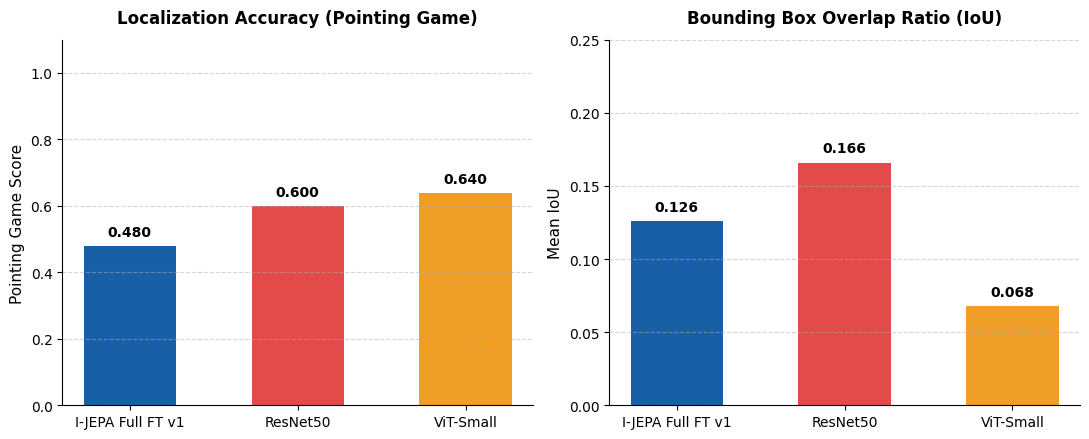

Saved: explainability_metrics_bar.png (High Resolution - 300 DPI)

=== FINAL SUMMARY ===


,pointing_game_score,overlap_ratio_mean,n_samples
model,,,
I-JEPA Full FT v1,0.48,0.1258,100
ResNet50,0.60,0.1660,100
ViT-Small,0.64,0.0677,100


In [13]:
# ============================================================
# CELL 13: ACADEMIC BAR CHART METRICS (PUBLICATION READY)
# ============================================================
if len(metric_df) > 0:
    # Sử dụng layout thoáng hơn, hạ nhẹ chiều cao để biểu đồ cân đối
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    models_list = summary.index.tolist()
    colors = {"ResNet50": "#E24B4A", "ViT-Small": "#EF9F27", "I-JEPA Full FT v1": "#185FA5"}

    # --- SUBPLOT 1: POINTING GAME SCORE ---
    pg_vals = [summary.loc[m, "pointing_game_score"] for m in models_list]
    bars    = axes[0].bar(range(len(models_list)), pg_vals,
                          color=[colors.get(m, "gray") for m in models_list],
                          edgecolor="none", width=0.55) # Thu hẹp độ rộng cột cho tinh tế
    
    axes[0].set_xticks(range(len(models_list)))
    # Vì chỉ có 3 mô hình, để chữ nằm ngang (rotation=0) giúp người đọc dễ nhìn hơn
    axes[0].set_xticklabels(models_list, fontsize=10, rotation=0, ha="center")
    axes[0].set_ylabel("Pointing Game Score", fontsize=11)
    axes[0].set_title("Localization Accuracy (Pointing Game)", fontsize=12, fontweight="bold", pad=12)
    axes[0].set_ylim(0, 1.1)
    axes[0].grid(True, axis="y", linestyle="--", alpha=0.5) # Đường lưới đứt nét nhẹ nhàng
    
    # Xóa viền trên và viền phải theo phong cách đồ thị học thuật hiện đại
    for spine in ["top", "right"]:
        axes[0].spines[spine].set_visible(False)
        
    for bar, val in zip(bars, pg_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="semibold")

    # --- SUBPLOT 2: OVERLAP RATIO (IoU) ---
    or_vals = [summary.loc[m, "overlap_ratio_mean"] for m in models_list]
    bars    = axes[1].bar(range(len(models_list)), or_vals,
                          color=[colors.get(m, "gray") for m in models_list],
                          edgecolor="none", width=0.55)
    
    axes[1].set_xticks(range(len(models_list)))
    axes[1].set_xticklabels(models_list, fontsize=10, rotation=0, ha="center")
    axes[1].set_ylabel("Mean IoU", fontsize=11)
    axes[1].set_title("Bounding Box Overlap Ratio (IoU)", fontsize=12, fontweight="bold", pad=12)
    # Thu hẹp ylim từ 0.6 xuống 0.25 vì giá trị max chỉ là 0.166, giúp cột cao và dễ quan sát rõ tỷ lệ chênh lệch
    axes[1].set_ylim(0, 0.25) 
    axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)
    
    for spine in ["top", "right"]:
        axes[1].spines[spine].set_visible(False)
        
    for bar, val in zip(bars, or_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="semibold")

    # LƯU Ý: Trong các bài báo quốc tế (LaTeX), tiêu đề chính phía trên cùng (suptitle) thường bị BỎ 
    # vì phần mô tả hình (Caption) dưới chân ảnh đã đảm nhiệm vai trò này.
    # Nếu bạn muốn giữ tiêu đề để xem offline, hãy bỏ dấu comment (#) ở dòng phía dưới:
    # plt.suptitle("Quantitative Evaluation of Model Explainability", fontsize=13, fontweight="bold", y=1.02)

    plt.tight_layout()
    # Tăng DPI lên 300 để ảnh không bị vỡ hạt khi chèn vào Overleaf/Word
    fig.savefig(OUTPUT_DIR / "explainability_metrics_bar.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: explainability_metrics_bar.png (High Resolution - 300 DPI)")

    print("\n=== FINAL SUMMARY ===")
    display(summary)
else:
    print("No metric data available for plotting.")

In [14]:
# ============================================================
# CELL 14: LƯU OUTPUT + NÉN
# ============================================================
# Dọn dẹp GPU
for m in models.values():
    del m
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

print("Files trong output:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(OUTPUT_DIR)):60s}  ({p.stat().st_size/1e3:.1f} KB)")

shutil.make_archive("/kaggle/working/notebook08_gradcam", "zip", OUTPUT_DIR)
print("\nCreated: notebook08_gradcam.zip")


Files trong output:
  explainability_figure_paper.png                               (1031.1 KB)
  explainability_metrics_bar.png                                (140.7 KB)
  metrics/explainability_metrics.csv                            (20.7 KB)
  metrics/explainability_summary.csv                            (0.1 KB)
  visualizations/normal_00_3e05d545.png                         (704.6 KB)
  visualizations/normal_01_de2e8b69.png                         (740.5 KB)
  visualizations/normal_02_fb8f1568.png                         (555.6 KB)
  visualizations/normal_03_fe56d8c1.png                         (733.0 KB)
  visualizations/pneumonia_00_dcc879b2.png                      (661.5 KB)
  visualizations/pneumonia_01_05fe7d73.png                      (692.7 KB)
  visualizations/pneumonia_02_6a82ef54.png                      (620.6 KB)
  visualizations/pneumonia_03_9ec108de.png                      (638.8 KB)
  visualizations/pneumonia_04_ef9fb572.png                      (615.0 KB)
  visua